In [1]:
# Shock analysis
# Plotting settings
import mesa
import pandas as pd
from helpers import plot_all_agent_graphs

# Graphs font
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette([
    "#8E44AD",  # violet/purple
    "#C08081",  # muted pinkish/brown
    "#f97743",  # bright orange
    "#2f6edd",  # royal blue
    "#28b36a",  # green
    "#1ABC9C",  # teal
    "#E74C3C",  # red
    "#333333",  # dark gray

])

import matplotlib.ticker as mtick
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}
import numpy as np
# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel



0
0.5
0.75
1.01
1.5
2
5
10


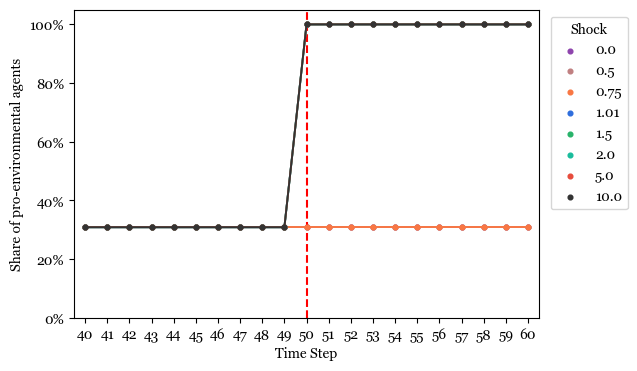

In [ ]:
# Round 1: Identity = 0
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1.01, 1.5, 2, 5, 10]
possible_shocks_dict_identity = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(10):
        model_shock_identity = statusgame_model(N=350, seed=666, lambda_s=0, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1, k=10, rho=1/3, 
                seed_consumption=False, 
                alpha=1/50, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock)

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_identity.step()
        # Add df to the list 
        model_shock_identity_df = model_shock_identity.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_identity_df = model_shock_identity_df.loc[model_shock_identity_df["Step"] >= 40]
        model_shock_identity_df["iteration"] = i 
        list_dfs_shock.append(model_shock_identity_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_identity[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_identity.keys():
    shock_df = possible_shocks_dict_identity[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_identity = pd.concat(list_final_dfs)

# Plot  
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_identity, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Time Step")
ax.set_ylabel("Share of pro-environmental agents")
ax.set_ylim(0,1.05)
ax.legend(title = "Shock (a)", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.savefig("results/shocks_lambda.pdf", bbox_inches = "tight", dpi=300)

0
0.5
0.75
1.01
1.5
2
5
10


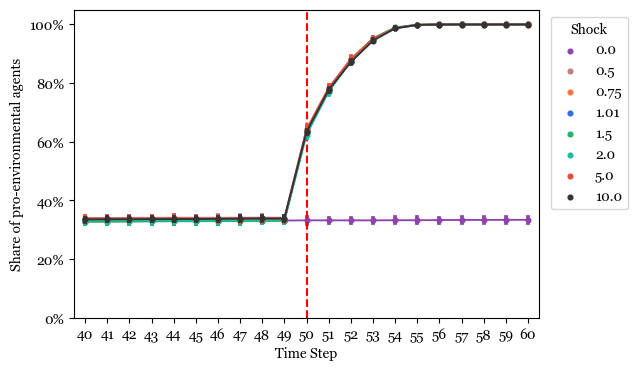

In [ ]:
# Round 2: Gamma = 1/500
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1.01, 1.5, 2, 5, 10]
possible_shocks_dict_gamma = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(35):
        model_shock_gamma = statusgame_model(N=350, seed=666, lambda_s=1, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1/500, k=10, rho=1/3, 
                seed_consumption=False, 
                alpha=1/50, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock,
                consumption_dist="gamma_dist")

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_gamma.step()
        # Add df to the list 
        model_shock_gamma_df = model_shock_gamma.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_gamma_df = model_shock_gamma_df.loc[model_shock_gamma_df["Step"] >= 40]
        model_shock_gamma_df["iteration"] = i 
        list_dfs_shock.append(model_shock_gamma_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_gamma[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_gamma.keys():
    shock_df = possible_shocks_dict_gamma[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_gamma = pd.concat(list_final_dfs)

# Plot 
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_gamma, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0,1.05)
ax.set_xlabel("Time Step")
ax.set_ylabel("Share of pro-environmental agents")
ax.legend(title = "Shock (a)", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.savefig("results/shocks_gamma.pdf", bbox_inches = "tight", dpi=300)

0
0.5
0.75
1.01
1.5
2
5
10


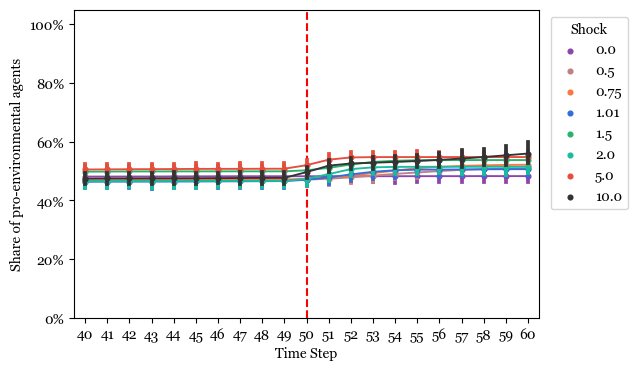

In [ ]:
# Round 3: Rules 
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1.01, 1.5, 2, 5, 10]
possible_shocks_dict_rules = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(35):
        model_shock_rules = statusgame_model(N=500, seed=666, lambda_s=1, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1, k=3, rho=1, 
                seed_consumption=False, 
                alpha=0, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock, 
                wait_gamma=True)

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_rules.step()
        # Add df to the list 
        model_shock_rules_df = model_shock_rules.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_rules_df = model_shock_rules_df.loc[model_shock_rules_df["Step"] >= 40]
        model_shock_rules_df["iteration"] = i 
        list_dfs_shock.append(model_shock_rules_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_rules[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_rules.keys():
    shock_df = possible_shocks_dict_rules[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_rules = pd.concat(list_final_dfs)

# Plot 
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_rules, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0,1.05)
ax.set_xlabel("Time Step")
ax.set_ylabel("Share of pro-environmental agents")
ax.legend(title = "Shock (a)", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig("results/shocks_rules.pdf", bbox_inches = "tight", dpi=300)

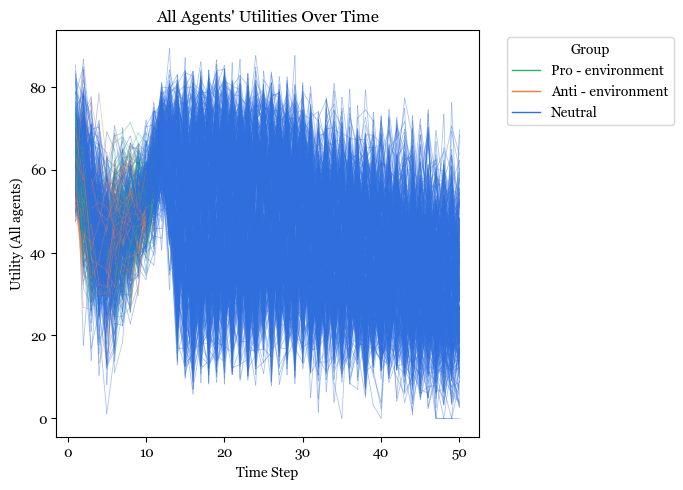

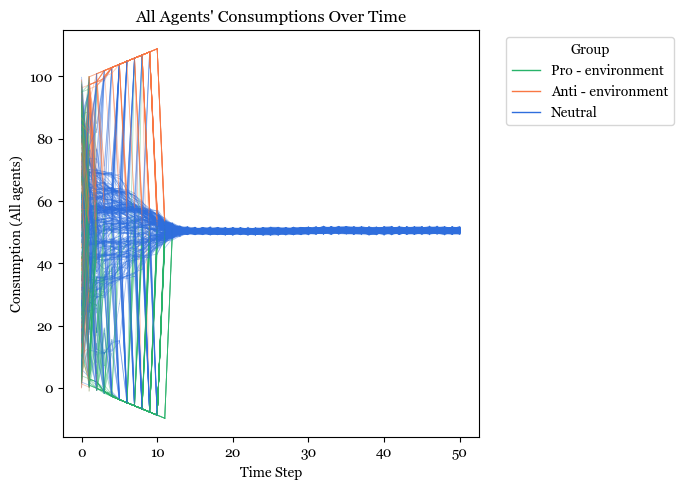

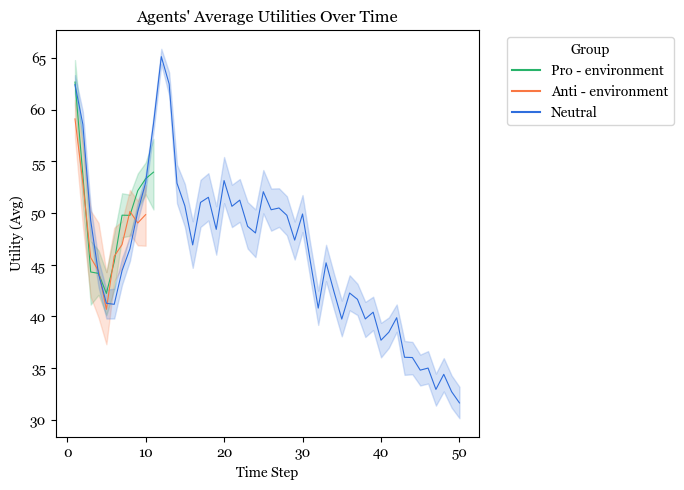

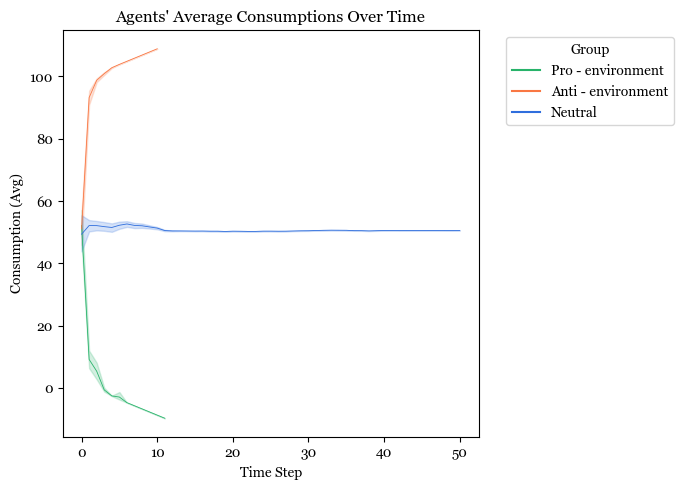

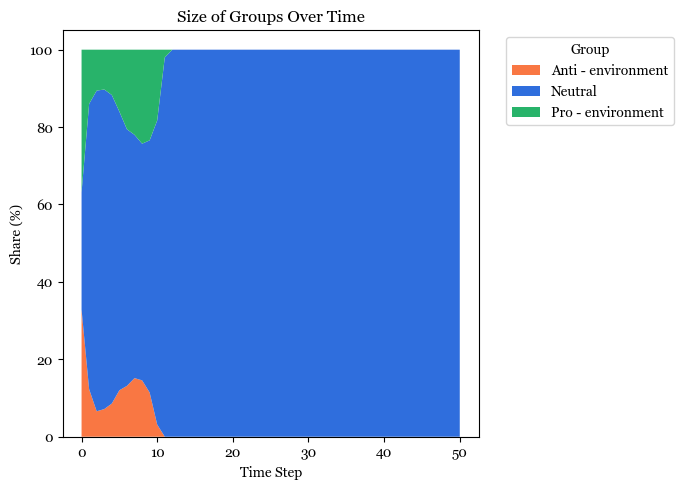

In [5]:
model_prop_neutral = statusgame_model(N=350, seed=1, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/100, gamma=1, k=10, rho=1/3, seed_consumption=True, alpha=1/20, weights=[1/3, 1/3, 1/3])

for _ in range(50):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(model_prop_neutral_df, color_dict, output_folder="results/fig2_computational", show_plots=True)